<a href="https://colab.research.google.com/github/LourdAbuHadid1/IE-332-Group-Assignments/blob/main/A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ipython-sql
%load_ext sql
%sql sqlite:///boilermaker_brews.db

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.6 MB/s eta 0:00:00


In [2]:
%%sql
# Run this setup cell as provided. No package installation is needed.
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display

DB_PATH = Path("boilermaker_brews.db")

if not DB_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "Place boilermaker_brews.db in the notebook's working folder."
        ) from exc
    print("Choose boilermaker_brews.db from the course files.")
    files.upload()

if not DB_PATH.exists():
    raise FileNotFoundError("boilermaker_brews.db was not uploaded.")

# These exercises only read data; protect the uploaded database from changes.
conn = sqlite3.connect(DB_PATH.resolve().as_uri() + "?mode=ro", uri=True)


class SQLResult(list):
    """Query rows and the information needed by the provided self-checks."""
    def __init__(self, frame, sql):
        super().__init__(frame.itertuples(index=False, name=None))
        self.keys = list(frame.columns)
        self.frame = frame
        self.sql = sql


def _sql_magic(line, cell):
    """Run SQL and display its result; %%sql q1 << also saves it as q1."""
    parts = line.split()
    if parts and (
        not parts[0].isidentifier()
        or len(parts) > 2
        or (len(parts) == 2 and parts[1] != "<<")
    ):
        raise ValueError("Use %%sql or a capture header such as %%sql q1 <<.")
    target = parts[0] if parts else None
    if target:
        # A failed rerun must not leave an earlier answer available to the check.
        get_ipython().user_ns[target] = None
    with conn:
        cursor = conn.execute(cell)
        if cursor.description is None:
            raise ValueError("Write a SELECT or WITH query below the %%sql header.")
        frame = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
    if target:
        get_ipython().user_ns[target] = SQLResult(frame, cell)
    display(frame)


get_ipython().register_magic_function(_sql_magic, "cell", "sql")


def _sql_line_magic(line):
    _sql_magic("", line)


get_ipython().register_magic_function(_sql_line_magic, "line", "sql")
print(f"Connected to {DB_PATH.name}. The %%sql command is ready.")


 * sqlite:///boilermaker_brews.db
(sqlite3.OperationalError) unrecognized token: "#"
[SQL: # Run this setup cell as provided. No package installation is needed.
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display

DB_PATH = Path("boilermaker_brews.db")

if not DB_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "Place boilermaker_brews.db in the notebook's working folder."
        ) from exc
    print("Choose boilermaker_brews.db from the course files.")
    files.upload()

if not DB_PATH.exists():
    raise FileNotFoundError("boilermaker_brews.db was not uploaded.")

# These exercises only read data; protect the uploaded database from changes.
conn = sqlite3.connect(DB_PATH.resolve().as_uri() + "?mode=ro", uri=True)


class SQLResult(list):
    """Query rows and the information needed by the provided self-checks."""
    def __init__(self, frame, sql):
 

Display the tables and the columns in the database

In [3]:
%%sql

SELECT
m.name AS table_name,
p.name AS column_name,
p.type AS data_type
FROM sqlite_master AS m
JOIN pragma_table_info(m.name) AS p
WHERE m.type = 'table'
AND m.name NOT LIKE 'sqlite_%'
ORDER BY m.name, p.cid;

 * sqlite:///boilermaker_brews.db
Done.


KeyError: 'DEFAULT'

In [ ]:
%config SqlMagic.style = 'PLAIN_COLUMNS'

# Question 1

In [ ]:
%%sql df_rev <<

-- Sorting by revenue
SELECT
    p.category,
    SUM(o.unit_price * o.quantity) AS revenue,
    SUM(o.quantity) AS units
FROM products AS p
JOIN order_items AS o
    ON p.product_id = o.product_id
GROUP BY p.category
ORDER BY revenue DESC;

In [ ]:
print(df_rev)

In [ ]:
%%sql df_units <<

-- Sorting by units
SELECT
    p.category,
    SUM(o.unit_price * o.quantity) AS revenue,
    SUM(o.quantity) AS units
FROM products AS p
JOIN order_items AS o
    ON p.product_id = o.product_id
GROUP BY p.category
ORDER BY units DESC;

In [ ]:
print(df_units)

the two categories that switch their relative order are "pastry" and "tea"

when ordering by revenue:
tea: $44795.50
pastry: $39935.30
tea ranks higher because it generated more total money

when ordering by units:
pastry: 13168 units
tea: 12196 units
pastry ranks higher because more individual pastry items were sold

# Question 2

In [ ]:
%%sql df_share <<

SELECT
s.name AS cafe,
ROUND(1.0 * SUM(CASE WHEN o.channel = 'app' THEN 1 ELSE 0 END)
/ COUNT(*),
3) AS app_share
FROM stores AS s
JOIN orders AS o
    ON s.store_id = o.store_id
GROUP BY s.name
ORDER BY app_share DESC;

,cafe,app_share
0,Chauncey Hill,0.305
1,Airport Rd Drive-Thru,0.302
2,Levee Plaza,0.301
3,PMU Ground Floor,0.300
4,State Street East,0.295
5,Discovery Park,0.295


In [ ]:
print(df_share)

[('Chauncey Hill', 0.305), ('Airport Rd Drive-Thru', 0.302), ('Levee Plaza', 0.301), ('PMU Ground Floor', 0.3), ('State Street East', 0.295), ('Discovery Park', 0.295)]


In [ ]:
%%sql df_summary <<

WITH shares AS (
    SELECT
        s.name AS cafe,
        ROUND(1.0 * SUM(CASE WHEN o.channel = 'app' THEN 1 ELSE 0 END)
        / COUNT(*), 6) AS app_share
    FROM stores AS s
    JOIN orders AS o
    ON s.store_id = o.store_id
    GROUP BY s.store_id, s.name
),
    highest AS (
      SELECT cafe, app_share
      FROM shares
      ORDER BY app_share DESC
      LIMIT 1
    ),
    lowest AS (
      SELECT cafe, app_share
      FROM shares
      ORDER BY app_share ASC
      LIMIT 1
    )
    SELECT highest.cafe AS highest_cafe,
    ROUND(highest.app_share, 6) AS highest_share,
    lowest.cafe AS lowest_cafe,
    ROUND(lowest.app_share, 6) AS lowest_share,
    ROUND(highest.app_share - lowest.app_share, 6) AS share_difference
    FROM highest, lowest;

,highest_cafe,highest_share,lowest_cafe,lowest_share,share_difference
0,Chauncey Hill,0.304657,State Street East,0.295098,0.009559


In [ ]:
print(df_summary)

[('Chauncey Hill', 0.304657, 'State Street East', 0.295098, 0.009559)]


**What does the difference show about similarity across cafes?**

The very small difference of 0.009559 shows that app-order shares are very similar across cafes, with less than a 1 percentage-point difference between the highest and lowest cafes.

# Question 3

# Question 4
Average spending per order by loyalty tier

In [ ]:
%%sql

WITH order_values AS (
    SELECT
        o.order_id,
        o.customer_id,
        SUM(oi.quantity * oi.unit_price) AS order_value
    FROM orders AS o
    JOIN order_items AS oi
        ON o.order_id = oi.order_id
    GROUP BY
        o.order_id,
        o.customer_id
),

labeled_orders AS (
    SELECT
        ov.order_id,
        ov.order_value,
        CASE
            WHEN ov.customer_id IS NULL THEN 'walk-in'
            ELSE c.loyalty_tier
        END AS loyalty_tier
    FROM order_values AS ov
    LEFT JOIN customers AS c
        ON ov.customer_id = c.customer_id
)

SELECT
    loyalty_tier,
    ROUND(AVG(order_value), 2) AS avg_order_value,
    COUNT(*) AS number_of_orders
FROM labeled_orders
GROUP BY loyalty_tier
ORDER BY CASE loyalty_tier
    WHEN 'gold' THEN 1
    WHEN 'silver' THEN 2
    WHEN 'none' THEN 3
    WHEN 'walk-in' THEN 4
END;

,loyalty_tier,avg_order_value,number_of_orders
0,gold,7.21,6496
1,silver,7.24,10698
2,none,7.20,16530
3,walk-in,7.19,18203


**What do the averages show about spending per order?**

The averages show that across all loyalty tiers the spending amount is relatively consistent. The highest spending was done by members in the silver tier, while the lowest by walk-ins. The range of spending is only 5 cents so it does not show a large difference in spending per order.

**Why can this result alone not establish that the program causes more visits, greater total spending per customer, or more profit?**

This result only tells us how much a customer spends on an individual visit, it does not give insight to how frequent the customer visits or how much they spend over time. It also does not account for the discounts or promotions that the higher tiers receive for being members so they could see lower order prices because of that.

# Question 5

In [ ]:
%%sql q5 <<

WITH monthly_revenue AS (
  SELECT
    strftime('%Y-%m', o.order_ts) AS month,
    SUM(oi.unit_price * oi.quantity) AS revenue
  FROM orders AS o
  JOIN order_items AS oi
    ON o.order_id = oi.order_id
  GROUP BY strftime('%Y-%m', o.order_ts)
)

  SELECT month, revenue
  FROM monthly_revenue
  WHERE revenue > (SELECT AVG(revenue)
  FROM monthly_revenue)
  ORDER BY month;

,month,revenue
0,2025-09,39629.65
1,2025-10,40557.75
2,2025-11,38093.40
3,2025-12,31841.50
4,2026-02,33479.20
5,2026-03,36437.90
6,2026-04,36347.95


In [ ]:
print(q5)

[('2025-09', 39629.65), ('2025-10', 40557.75), ('2025-11', 38093.4), ('2025-12', 31841.5), ('2026-02', 33479.2), ('2026-03', 36437.9), ('2026-04', 36347.95)]


**Which of these periods contain the returned months?**

The returned months are in fall and spring, indicating that revenue tends to be higher during the academic periods than summer.

# Question 6:

In [ ]:
%%sql q6 <<

WITH monthly_revenue AS (
  SELECT
    p.category,
    strftime('%Y-%m', o.order_ts) AS month,
    SUM(oi.unit_price * oi.quantity) AS revenue
  FROM orders AS o
  JOIN order_items AS oi
    ON o.order_id = oi.order_id
  JOIN products AS p
    ON oi.product_id = p.product_id
    GROUP BY strftime('%Y-%m', o.order_ts), p.category
)

  SELECT category, month, revenue
  FROM monthly_revenue as m
  WHERE revenue = (SELECT MAX(m2.revenue)
  FROM monthly_revenue AS m2
  WHERE m2.category = m.category)
  ORDER BY category;


,category,month,revenue
0,brew,2026-03,7485.40
1,espresso,2025-10,25169.25
2,food,2026-04,2609.75
3,merch,2026-04,384.00
4,pastry,2026-04,4549.80
5,tea,2026-03,5285.75


In [ ]:
print(q6)

[('brew', '2026-03', 7485.400000000001), ('espresso', '2025-10', 25169.25), ('food', '2026-04', 2609.75), ('merch', '2026-04', 384.0), ('pastry', '2026-04', 4549.8), ('tea', '2026-03', 5285.75)]


# Question 7

# Question 8

# Question 9
Daypart order counts and shares by café.

a) Cafe-daypart

In [ ]:
%%sql

WITH cafe_daypart AS (
    SELECT
        s.name AS cafe,
        CASE
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 0 AND 10
                THEN 'morning'
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 11 AND 15
                THEN 'afternoon'
            ELSE 'evening'
        END AS daypart,
        COUNT(*) AS n_orders
    FROM orders AS o
    JOIN stores AS s
        ON o.store_id = s.store_id
    GROUP BY s.name, daypart
),

cafe_totals AS (
    SELECT
        s.name AS cafe,
        COUNT(*) AS cafe_orders
    FROM orders AS o
    JOIN stores AS s
        ON o.store_id = s.store_id
    GROUP BY s.name
)

SELECT
    c.cafe,
    c.daypart,
    c.n_orders,
    t.cafe_orders,
    ROUND(1.0 * c.n_orders / t.cafe_orders, 3) AS share
FROM cafe_daypart AS c
JOIN cafe_totals AS t
    ON c.cafe = t.cafe
ORDER BY
    c.cafe,
    CASE c.daypart
        WHEN 'morning' THEN 1
        WHEN 'afternoon' THEN 2
        WHEN 'evening' THEN 3
    END;

,cafe,daypart,n_orders,cafe_orders,share
0,Airport Rd Drive-Thru,morning,3910,8258,0.473
1,Airport Rd Drive-Thru,afternoon,3112,8258,0.377
2,Airport Rd Drive-Thru,evening,1236,8258,0.150
3,Chauncey Hill,morning,4238,8869,0.478
4,Chauncey Hill,afternoon,3358,8869,0.379
5,Chauncey Hill,evening,1273,8869,0.144
6,Discovery Park,morning,2408,4822,0.499
7,Discovery Park,afternoon,1789,4822,0.371
8,Discovery Park,evening,625,4822,0.130
9,Levee Plaza,morning,3406,7003,0.486


b) Share ranges

In [ ]:
%%sql

WITH cafe_daypart AS (
    SELECT
        s.name AS cafe,
        CASE
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 0 AND 10
                THEN 'morning'
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 11 AND 15
                THEN 'afternoon'
            ELSE 'evening'
        END AS daypart,
        COUNT(*) AS n_orders
    FROM orders AS o
    JOIN stores AS s
        ON o.store_id = s.store_id
    GROUP BY s.name, daypart
),

cafe_totals AS (
    SELECT
        s.name AS cafe,
        COUNT(*) AS cafe_orders
    FROM orders AS o
    JOIN stores AS s
        ON o.store_id = s.store_id
    GROUP BY s.name
),

shares AS (
    SELECT
        c.cafe,
        c.daypart,
        ROUND(1.0 * c.n_orders / t.cafe_orders, 3) AS share
    FROM cafe_daypart AS c
    JOIN cafe_totals AS t
        ON c.cafe = t.cafe
)

SELECT
    daypart,
    MIN(share) AS min_share,
    MAX(share) AS max_share
FROM shares
GROUP BY daypart
ORDER BY CASE daypart
    WHEN 'morning' THEN 1
    WHEN 'afternoon' THEN 2
    WHEN 'evening' THEN 3
END;

,daypart,min_share,max_share
0,morning,0.471,0.499
1,afternoon,0.369,0.379
2,evening,0.130,0.150


c) Cafe order extremes

Highest number of orders

In [ ]:
%%sql

SELECT
    s.name AS cafe,
    COUNT(*) AS total_orders
FROM orders AS o
JOIN stores AS s
    ON o.store_id = s.store_id
GROUP BY s.name
ORDER BY total_orders DESC
LIMIT 1;

,cafe,total_orders
0,PMU Ground Floor,16916


Lowest number of orders

In [ ]:
%%sql

SELECT
    s.name AS cafe,
    COUNT(*) AS total_orders
FROM orders AS o
JOIN stores AS s
    ON o.store_id = s.store_id
GROUP BY s.name
ORDER BY total_orders ASC
LIMIT 1;

,cafe,total_orders
0,Discovery Park,4822


# Question 10

# ERD
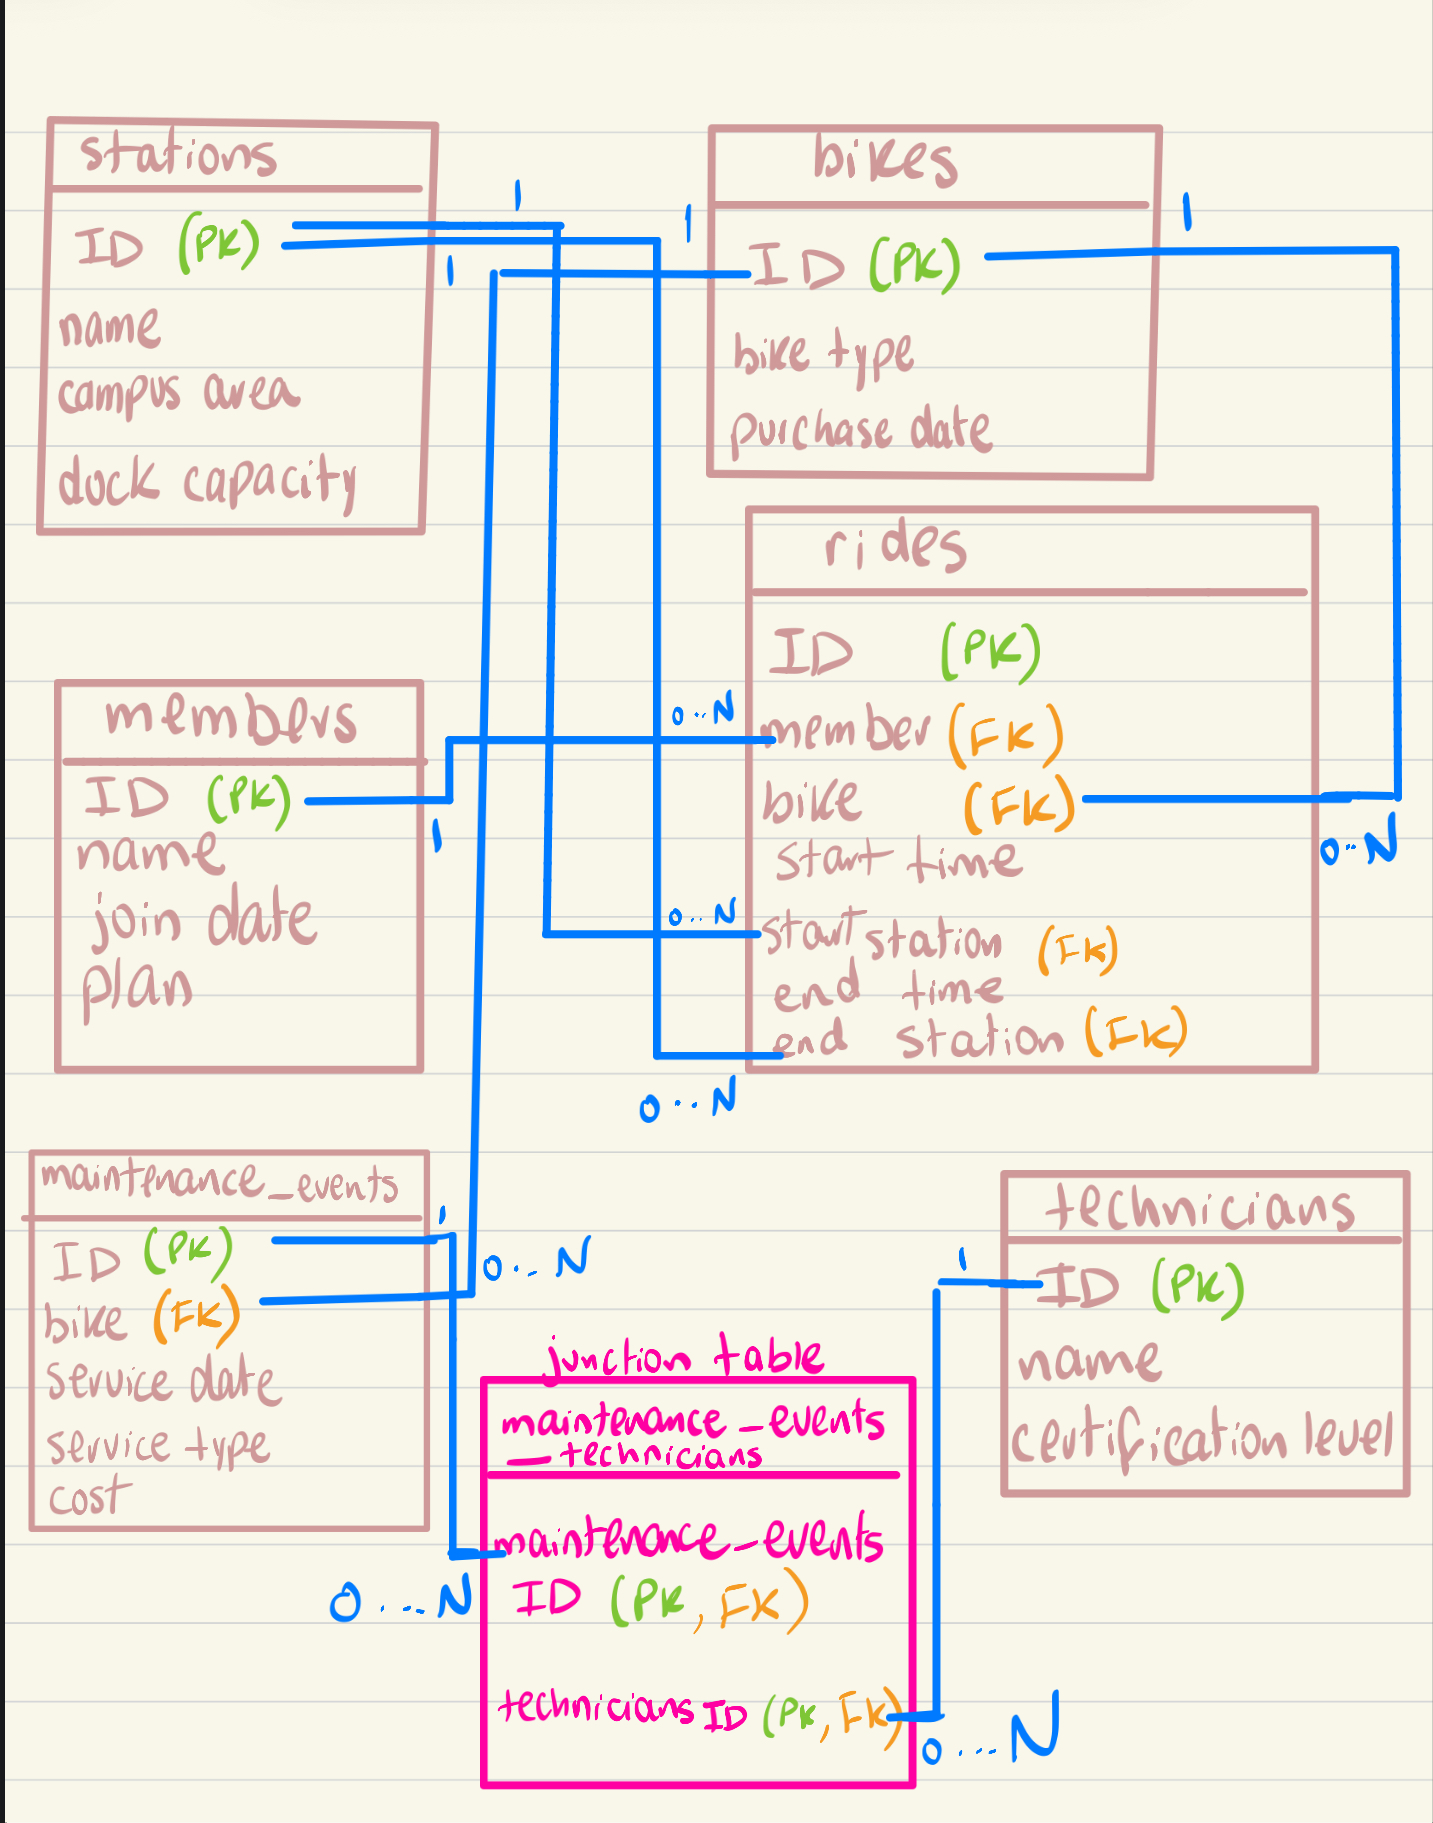

 **Grains:**

stations: one row represents one station

bikes: one row represents one bike

members: one row represents one member

rides: one row represents one bike ride

maintenance_events:one row represents one maintenance event for a bike

technicians:one row represents one technician

maintenance_events_technicians: one row represents a pairing of one maintenance event with one technician
